# Analysis of fake and real news data sets

In [34]:
import pandas as pd


def data_extract(df, target_value):
    """
    Extracts the text and title from the dataframe and  adds a label column.
    """

    # add a target column to the dataframe
    df["label"] = target_value

    # return a df copy with text, title and label columns
    return df[["text", "title", "label"]]


DATA_CONFIG = [
    {
        "name": "BuzzFeed Fake News",
        "description": "Fake news articles from BuzzFeed.",
        "filename": "BuzzFeed_fake_news_content.csv",
        "extract_func": data_extract,
        "target_value": "FAKE",
    },
    {
        "name": "BuzzFeed Real News",
        "description": "Real news articles from BuzzFeed.",
        "filename": "BuzzFeed_real_news_content.csv",
        "extract_func": data_extract,
        "target_value": "TRUE",
    },
    {
        "name": "PolitiFact Fake News",
        "description": "Fake news articles from PolitiFact.",
        "filename": "PolitiFact_fake_news_content.csv",
        "extract_func": data_extract,
        "target_value": "FAKE",
    },
    {
        "name": "PolitiFact Real News",
        "description": "Real news articles from PolitiFact.",
        "filename": "PolitiFact_real_news_content.csv",
        "extract_func": data_extract,
        "target_value": "TRUE",
    },
    {
        "name": "Fake News - Kaggle",
        "description": "Fake news articles from various sources obtained from kaggle.",
        "filename": "Fake.csv",
        "extract_func": data_extract,
        "target_value": "FAKE"
    },
    {
        "name": "True News - Kaggle",
        "description": "True news articles from various sources obtained from kaggle.",
        "filename": "True.csv", 
        "extract_func": data_extract, 
        "target_value": "TRUE"
    },
]


def load_merge_data(data_config):
    """
    Loads and merges the data from the given config.
    """
    dataframes = []

    for config in data_config:
        filepath = f"./data/{config['filename']}"
        df = pd.read_csv(filepath)
        df = config["extract_func"](df, config["target_value"])
        dataframes.append(df)

    # concatenate all dataframes into one
    merged_df = pd.concat(dataframes, ignore_index=True)

    return merged_df


def basic_sanity_check(df):
    """
    Performs a basic sanity check on the dataframe.
    """

    # sanity check title
    print("=" * 20)
    print("{:^20}".format("Sanity Check"))
    print("=" * 20)

    # check for missing values
    if df.isnull().values.any():
        print("Missing values found in the dataframe.")
        # remove rows with missing values
        df = df.dropna()

    # check for duplicates
    if df.duplicated().any():
        # check for duplicate rows
        duplicate_rows = df.duplicated().sum()
        print(f"Duplicate rows found: {duplicate_rows}")
        # remove duplicate rows
        df = df.drop_duplicates().reset_index(drop=True)
        print("Duplicate rows removed.")

    # check for empty strings
    if (df["text"] == "").any() or (df["title"] == "").any():
        print("Empty strings found in the dataframe.")
        # remove rows with empty strings
        df = df[(df["text"] != "") & (df["title"] != "")].reset_index(drop=True)
        print("Empty strings removed.")

    # check the shape of the dataframe
    print(f"Dataframe has {df.shape[0]} rows and {df.shape[1]} columns.")
    print(f"Dataframe has {df['label'].nunique()} unique labels.")

    print("=" * 20)


def save_data(df, path):
    """
    Saves the dataframe to a csv file.
    """
    df.to_csv(path, index=False)
    print(f"Data saved to {path}")


def generate_raw_data():
    raw_data = load_merge_data(DATA_CONFIG)
    basic_sanity_check(raw_data)
    save_data(raw_data, "./data/raw_data.csv")
    return raw_data


def load_raw_data():
    """
    Loads the raw data from the given path.
    """
    filepath = "./data/raw_data.csv"

    # check if the file exists, if not generate the raw data
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        print(f"{filepath} not found. Generating raw data...")
        df = generate_raw_data()
        print(f"Raw data generated and saved to {filepath}.")
    return df

In [35]:
df = load_raw_data()

df.head()

,text,title,label
0,I woke up this morning to find a variation of ...,Proof The Mainstream Media Is Manipulating The...,FAKE
1,Former President Bill Clinton and his Clinton ...,Charity: Clinton Foundation Distributed “Water...,FAKE
2,After collapsing just before trying to step in...,A Hillary Clinton Administration May be Entire...,FAKE
3,"Donald Trump is, well, deplorable. He’s sugges...",Trump’s Latest Campaign Promise May Be His Mos...,FAKE
4,Website is Down For Maintenance,Website is Down For Maintenance,FAKE


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

def show_class_distribution(df):
    class_counts = df["label"].value_counts()
    plt.figure(figsize=(6, 4))
    sns.barplot(x=class_counts.index, y=class_counts.values, palette=["red", "green"])
    plt.title("Class Distribution (FAKE vs TRUE)")
    plt.ylabel("Number of Samples")
    plt.xlabel("News Type")
    plt.show()
    
    print("Class Counts:\n", class_counts)
    print("\nPercentage Distribution:")
    print((class_counts / class_counts.sum() * 100).round(2))

C:\Users\u3253992\AppData\Local\Temp\ipykernel_10420\3912015479.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette=["red", "green"])


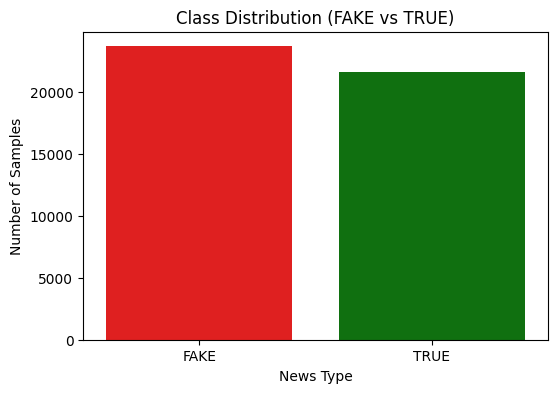

Class Counts:
 label
FAKE    23692
TRUE    21628
Name: count, dtype: int64

Percentage Distribution:
label
FAKE    52.28
TRUE    47.72
Name: count, dtype: float64


In [37]:
show_class_distribution(df)

In [38]:
def plot_text_lengths(df):
    df["text_len"] = df["text"].apply(lambda x: len(x.split()))
    
    plt.figure(figsize=(10, 5))
    sns.histplot(data=df, x="text_len", hue="label", bins=50, kde=True, palette=["red", "green"])
    plt.title("Distribution of Text Lengths by Class")
    plt.xlabel("Number of Words in Article")
    plt.ylabel("Frequency")
    plt.show()

    print("Average Lengths:")
    print(df.groupby("label")["text_len"].mean().round(2))
    print("\nStandard Deviations:")
    print(df.groupby("label")["text_len"].std().round(2))

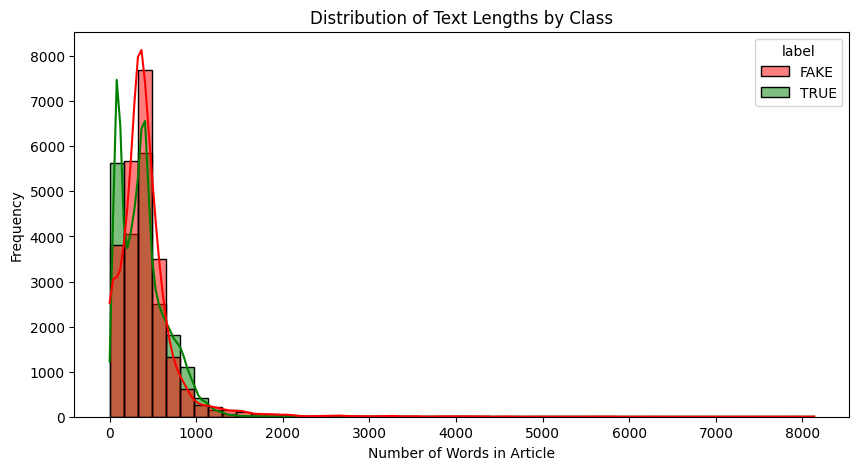

Average Lengths:
label
FAKE    424.45
TRUE    387.97
Name: text_len, dtype: float64

Standard Deviations:
label
FAKE    410.74
TRUE    283.41
Name: text_len, dtype: float64


In [39]:
plot_text_lengths(df)

In [ ]:
from nltk.corpus import stopwords
from collections import Counter

def stopword_distribution_grouped(df, top_n=10):
    stop_words = set(stopwords.words("english"))

    # Combine all words from FAKE and TRUE separately
    fake_words = " ".join(df[df["label"] == "FAKE"]["text"]).lower().split()
    true_words = " ".join(df[df["label"] == "TRUE"]["text"]).lower().split()

    # Filter stopwords
    fake_stops = [word for word in fake_words if word in stop_words]
    true_stops = [word for word in true_words if word in stop_words]

    # Count top N stopwords in both
    fake_common = Counter(fake_stops).most_common(top_n)
    true_common = Counter(true_stops).most_common(top_n)

    # Union of top stopwords across both classes
    all_stopwords = list(set([word for word, _ in fake_common + true_common]))

    # Prepare data
    data = []
    for word in all_stopwords:
        data.append({
            "stopword": word,
            "label": "FAKE",
            "count": dict(fake_common).get(word, 0)
        })
        data.append({
            "stopword": word,
            "label": "TRUE",
            "count": dict(true_common).get(word, 0)
        })

    df_plot = pd.DataFrame(data)

    # Pivot for better grouping order (optional)
    df_plot["stopword"] = pd.Categorical(df_plot["stopword"], 
                                         categories=sorted(all_stopwords, key=lambda w: (dict(fake_common).get(w, 0) + dict(true_common).get(w, 0))),
                                         ordered=True)

    # Plot grouped horizontal bar chart
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=df_plot,
        y="stopword",
        x="count",
        hue="label",
        orient="h",
        palette={"FAKE": "red", "TRUE": "green"}
    )
    plt.title("Top Stopwords in FAKE vs TRUE News")
    plt.xlabel("Frequency")
    plt.ylabel("Stopword")
    plt.legend(title="Label")
    plt.tight_layout()
    plt.show()

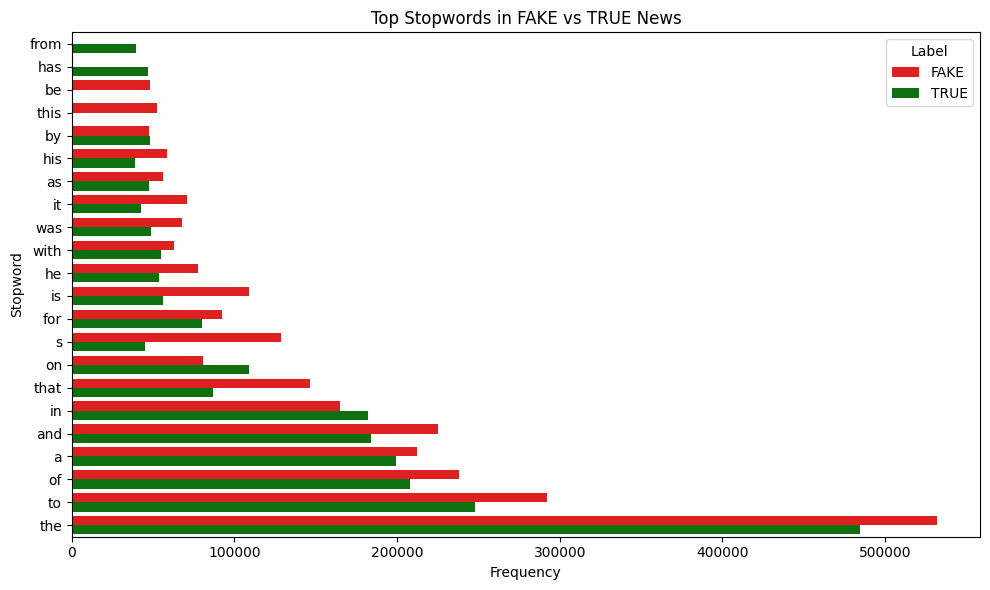

In [65]:
stopword_distribution_grouped(df, top_n=20)

In [61]:
from nltk.corpus import stopwords
from collections import Counter

def stopword_class_differentiation(df, top_n=15):
    stop_words = set(stopwords.words("english"))

    # Combine words for each label
    fake_words = " ".join(df[df["label"] == "FAKE"]["text"]).lower().split()
    true_words = " ".join(df[df["label"] == "TRUE"]["text"]).lower().split()

    # Count stopwords
    fake_counts = Counter([w for w in fake_words if w in stop_words])
    true_counts = Counter([w for w in true_words if w in stop_words])

    # Union of all stopwords seen
    all_stopwords = set(fake_counts.keys()) | set(true_counts.keys())

    data = []
    for word in all_stopwords:
        fake = fake_counts.get(word, 0)
        true = true_counts.get(word, 0)
        total = fake + true
        if total == 0:
            continue
        diff = (fake - true) / total  # range [-1, +1]
        data.append({
            "stopword": word,
            "fake_count": fake,
            "true_count": true,
            "diff_score": diff
        })

    df_diff = pd.DataFrame(data)

    # Sort by absolute value of difference to get the most polarizing stopwords
    df_diff["abs_diff"] = df_diff["diff_score"].abs()
    top_diff = df_diff.sort_values("abs_diff", ascending=False).head(top_n)

    # Plot horizontal bars with FAKE on left and TRUE on right
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top_diff,
        y="stopword",
        x="diff_score",
        palette="coolwarm",
        orient="h",
        legend=True,
        hue="diff_score",
        hue_norm=(-1, 1),
    )
    plt.axvline(0, color="gray", linestyle="--")
    plt.title("Top Distinguishing Stopwords Between FAKE and TRUE News")
    plt.xlabel("Relative Usage (Negative = TRUE, Positive = FAKE)")
    plt.ylabel("Stopword")
    plt.tight_layout()
    plt.show()


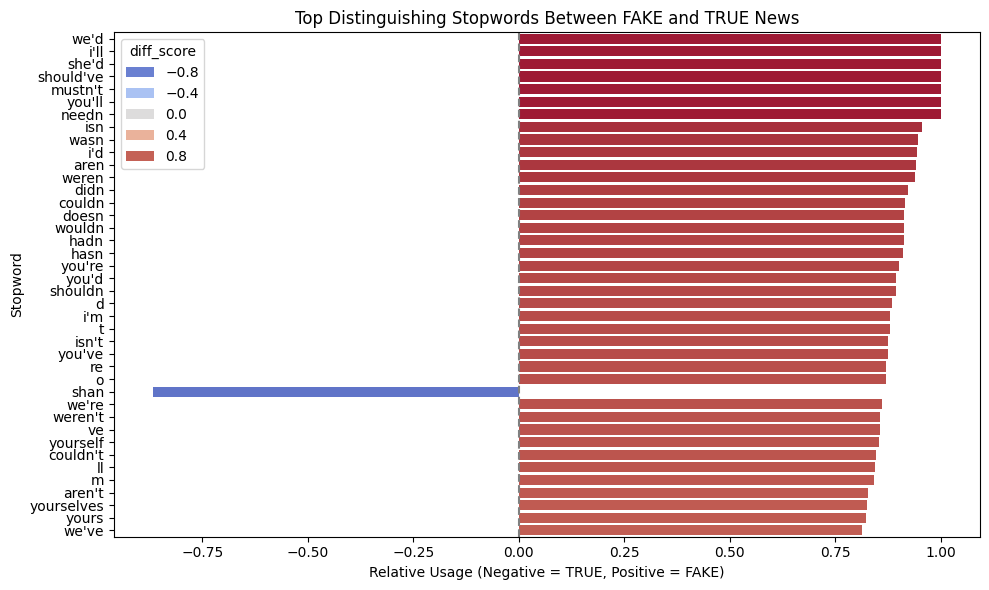

In [63]:
stopword_class_differentiation(df, top_n=40)

In [42]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download necessary resources
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")
nltk.download("wordnet")

# Custom stopwords (retain "not" and "can")
STOP_WORDS = set(stopwords.words("english")) - {"not", "can"}

# custom stopwords
CUSTOM_STOP_WORDS = {"reuters", "reuter"}

# Combine the two sets of stopwords
STOP_WORDS = STOP_WORDS.union(CUSTOM_STOP_WORDS)


# Function for preprocessing
def clean_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r"\'t", " not", text)  # Expand "can't" → "can not"
    text = re.sub(r"@\w+", "", text)  # Remove @name
    text = re.sub(r"[^a-zA-Z0-9\s\?]", "", text)  # Remove special characters except "?"
    text = re.sub(r"([^\w\s\?])", "", text)  # Remove punctuations except "?"
    text = re.sub(
        r"\s+", " ", text
    ).strip()  # Remove extra spaces and trailing whitespaces
    text = re.sub(r"\s+", " ", text)  # Remove extra spaces

    # remove stopwords
    text = " ".join([word for word in text.split() if word not in STOP_WORDS])

    return text


# function to tokenize the text and remove stopwords
def tokenize_text(text):
    # Tokenize the text
    tokens = word_tokenize(text)
    # Remove stopwords
    tokens = [word for word in tokens if word not in STOP_WORDS]
    return tokens


def lemmatize_tokens(tokens):   
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(token) for token in tokens]


def preprocess_data(df):
    """
    Preprocess the data by cleaning the text and removing stopwords.
    """
    # clean title
    df["title"] = df["title"].apply(clean_text)

    # clean text
    df["text"] = df["text"].apply(clean_text)

    # create a new column called 'news', by merging the 'title' and 'text' columns
    df["news"] = df["title"] + " " + df["text"]

    # tokenize the news text and remove stopwords
    df["tokens"] = df["news"].apply(tokenize_text)

    # lemmatize the tokens
    df["tokens"] = df["tokens"].apply(lemmatize_tokens)

    # merge the tokens into a single string
    df["cleaned_news"] = df["tokens"].apply(lambda x: " ".join(x))

    # return all columns in order
    df_cleaned = df[["title", "text", "news", "tokens", "cleaned_news", "label"]]

    return df_cleaned


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [43]:
df_clean = preprocess_data(df.copy())

# copy of the cleaned data for model training
df_clean_copy = df_clean.copy()

In [66]:
df_clean_copy.head()

,title,text,news,tokens,cleaned_news,label
0,proof mainstream media manipulating election t...,woke morning find variation headline splashed ...,proof mainstream media manipulating election t...,"[proof, mainstream, medium, manipulating, elec...",proof mainstream medium manipulating election ...,FAKE
1,charity clinton foundation distributed watered...,former president bill clinton clinton health a...,charity clinton foundation distributed watered...,"[charity, clinton, foundation, distributed, wa...",charity clinton foundation distributed watered...,FAKE
2,hillary clinton administration may entirely ru...,collapsing trying step van removed 911 ceremon...,hillary clinton administration may entirely ru...,"[hillary, clinton, administration, may, entire...",hillary clinton administration may entirely ru...,FAKE
3,trumps latest campaign promise may horrible on...,donald trump well deplorable hes suggested bui...,trumps latest campaign promise may horrible on...,"[trump, latest, campaign, promise, may, horrib...",trump latest campaign promise may horrible one...,FAKE
4,website maintenance,website maintenance,website maintenance website maintenance,"[website, maintenance, website, maintenance]",website maintenance website maintenance,FAKE


In [44]:
from wordcloud import WordCloud

def generate_wordcloud(text, title, color="black"):
    wordcloud = WordCloud(width=800, height=400, background_color=color).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=18)
    plt.show()

def show_wordclouds(df):
    fake_text = " ".join(df[df["label"] == "FAKE"]["cleaned_news"])
    real_text = " ".join(df[df["label"] == "TRUE"]["cleaned_news"])
    
    generate_wordcloud(fake_text, "Word Cloud: FAKE News", color="white")
    generate_wordcloud(real_text, "Word Cloud: TRUE News", color="white")


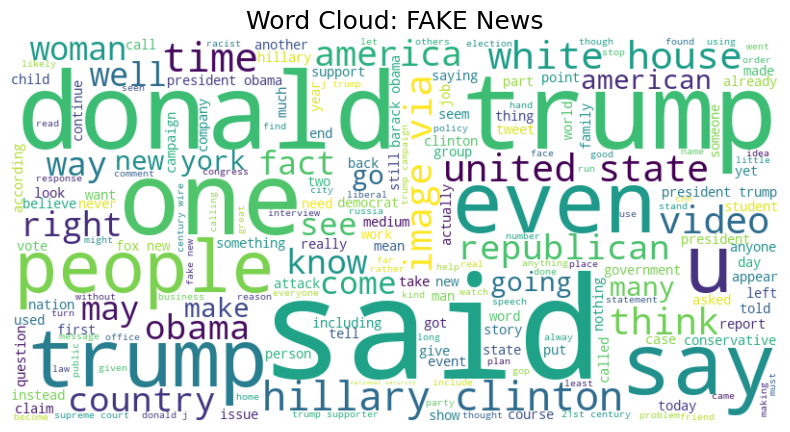

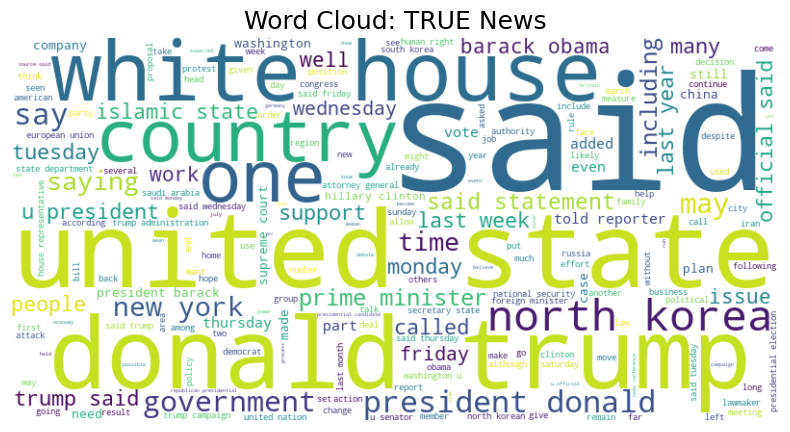

In [45]:
show_wordclouds(df_clean_copy)

In [80]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def content_word_differentiation(df, top_n=20):
    # Flatten tokens
    fake_tokens = df[df["label"] == "FAKE"]["tokens"].explode()
    true_tokens = df[df["label"] == "TRUE"]["tokens"].explode()

    # Count word frequencies (non-stopwords already handled in tokenization step)
    fake_counts = Counter(fake_tokens)
    true_counts = Counter(true_tokens)

    # All words seen in either class
    all_words = set(fake_counts.keys()) | set(true_counts.keys())

    # Prepare comparison data
    data = []
    for word in all_words:
        fake = fake_counts.get(word, 0)
        true = true_counts.get(word, 0)
        total = fake + true
        if total < 20000:  # filter rare words
            continue
        diff = (fake - true) / total
        data.append({
            "word": word,
            "fake_count": fake,
            "true_count": true,
            "diff_score": diff
        })

    # Convert to DataFrame
    df_diff = pd.DataFrame(data)
    df_diff["abs_diff"] = df_diff["diff_score"].abs()

    # Sort and pick top N
    top_diff = df_diff.sort_values("abs_diff", ascending=False).head(top_n)

    # Plot horizontal bar chart
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top_diff,
        y="word",
        x="diff_score",
        palette="coolwarm",
        orient="h",
        legend=True,
        hue="diff_score",
        hue_norm=(-1, 1),
    )
    plt.axvline(0, color="gray", linestyle="--")
    plt.title("Top Distinguishing Content Words Between FAKE and TRUE News")
    plt.xlabel("Relative Usage (Negative = TRUE, Positive = FAKE)")
    plt.ylabel("Word")
    plt.tight_layout()
    plt.show()

    return top_diff.sort_values("diff_score", ascending=True)


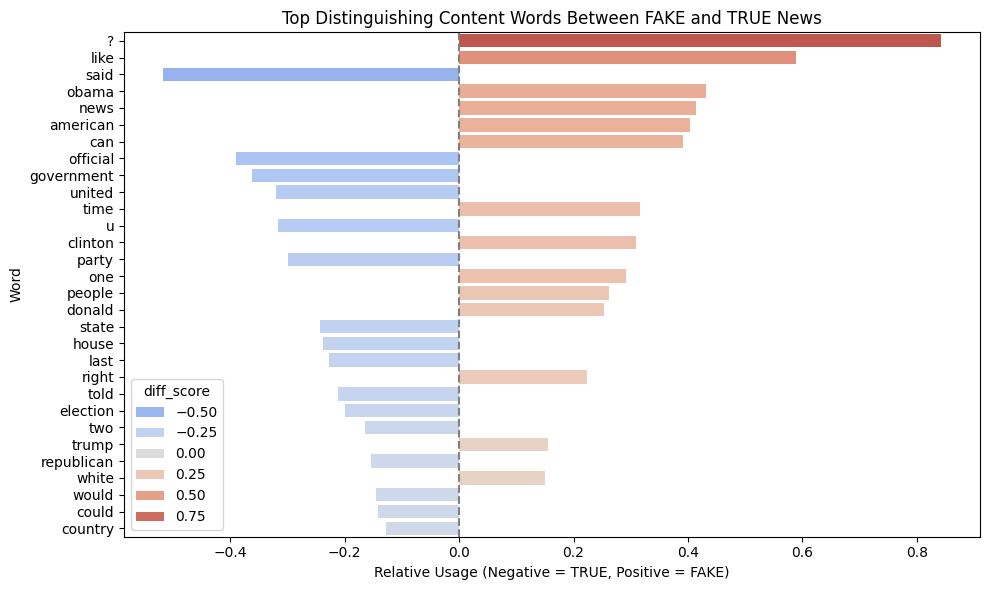

,word,fake_count,true_count,diff_score,abs_diff
5,said,31717,99798,-0.517667,0.517667
9,official,6672,15207,-0.390100,0.390100
16,government,9356,19979,-0.362127,0.362127
26,united,8113,15727,-0.319379,0.319379
27,u,23660,45503,-0.315819,0.315819
29,party,8377,15492,-0.298085,0.298085
4,state,22875,37513,-0.242399,0.242399
22,house,11378,18477,-0.237783,0.237783
7,last,8086,12837,-0.227071,0.227071
36,told,9374,14420,-0.212070,0.212070


In [81]:
content_word_differentiation(df_clean_copy, top_n=30)